In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Update these paths to match your folder structure
DATA_DIR = "C:/Users/Gorata/IndabaX/Data_Clean"

In [3]:
prediction_df = pd.read_csv(f"{DATA_DIR}/prediction_data.csv")

In [4]:
prediction_df.head()

,year_month,FAO_23012,FAO_23013,FAO_23014,BDI_std,first,last,monthly_return_bdi,Brent_USD_per_barrel,policy_rate
0,2001-01,34.291207,33.061978,3.602384,29.297289,1599,1504,-0.059412,25.62,14.0
1,2001-02,34.341562,33.243495,3.359312,29.086577,1493,1537,0.029471,27.50,14.0
2,2001-03,34.643687,33.295356,2.720000,24.971716,1538,1438,-0.065020,24.50,14.0
3,2001-04,34.794749,33.321287,2.173337,16.162009,1430,1459,0.020280,25.66,14.0
4,2001-05,35.273114,33.476873,2.028451,26.959493,1453,1389,-0.044047,28.31,14.0


In [5]:
# Correct date format
prediction_df["date"] = pd.to_datetime(prediction_df["year_month"] + "-01")
prediction_df = prediction_df.sort_values("date").reset_index(drop=True)

In [6]:
# Name target properly
prediction_df = prediction_df.rename(columns={"FAO_23014": "food_price_inflation"})

In [7]:
prediction_df.head()

,year_month,FAO_23012,FAO_23013,food_price_inflation,BDI_std,first,last,monthly_return_bdi,Brent_USD_per_barrel,policy_rate,date
0,2001-01,34.291207,33.061978,3.602384,29.297289,1599,1504,-0.059412,25.62,14.0,2001-01-01
1,2001-02,34.341562,33.243495,3.359312,29.086577,1493,1537,0.029471,27.50,14.0,2001-02-01
2,2001-03,34.643687,33.295356,2.720000,24.971716,1538,1438,-0.065020,24.50,14.0,2001-03-01
3,2001-04,34.794749,33.321287,2.173337,16.162009,1430,1459,0.020280,25.66,14.0,2001-04-01
4,2001-05,35.273114,33.476873,2.028451,26.959493,1453,1389,-0.044047,28.31,14.0,2001-05-01


In [8]:
prediction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   year_month            276 non-null    object        
 1   FAO_23012             276 non-null    float64       
 2   FAO_23013             276 non-null    float64       
 3   food_price_inflation  276 non-null    float64       
 4   BDI_std               276 non-null    float64       
 5   first                 276 non-null    int64         
 6   last                  276 non-null    int64         
 7   monthly_return_bdi    276 non-null    float64       
 8   Brent_USD_per_barrel  276 non-null    float64       
 9   policy_rate           276 non-null    float64       
 10  date                  276 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(7), int64(2), object(1)
memory usage: 23.8+ KB


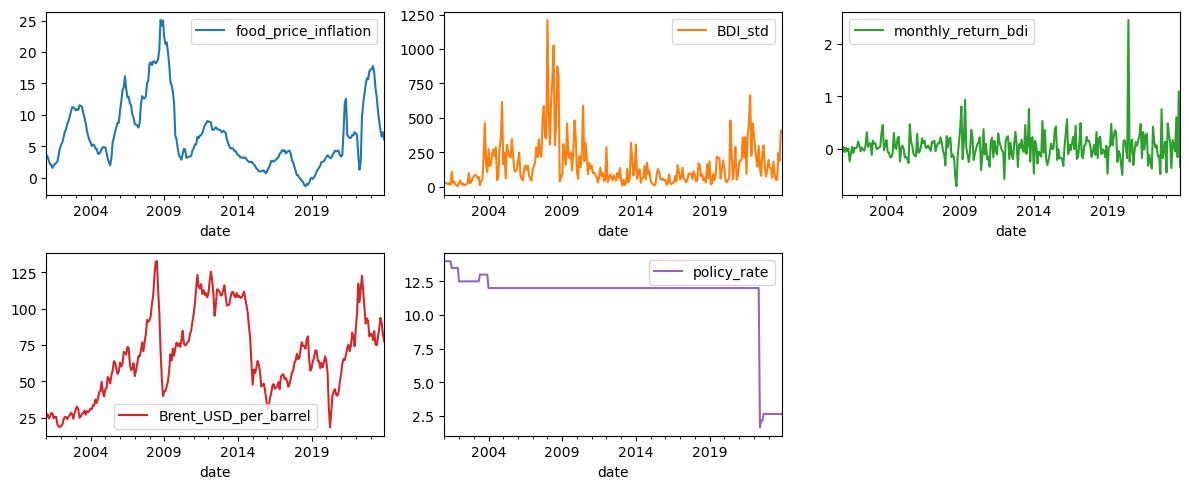

In [9]:
# Inspect time series
prediction_df.plot(x="date", y=["food_price_inflation", "BDI_std", "monthly_return_bdi", "Brent_USD_per_barrel", 
               "policy_rate"], subplots=True, layout=(2, 3), figsize=(12, 5), sharex=False)

plt.tight_layout()
plt.show()

# Check for Linearity
Before attempting to use complex models like Gradient Boosted Trees, we have to attempt linear models and simple techniques like ARIMAX. To do this, we first have to check if the data satisfies or violates assumptions required for these simple models.

C:\Users\Gorata\anaconda3\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


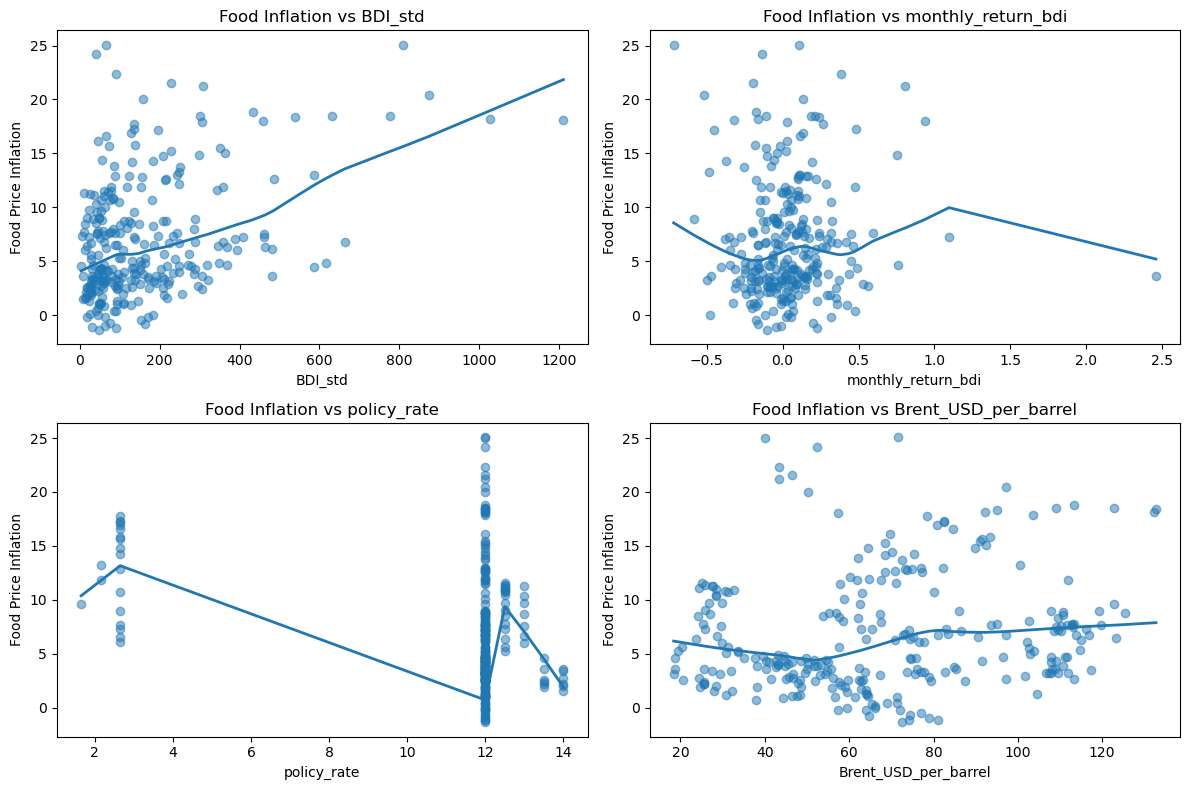

In [10]:
features = [
    "BDI_std",
    "monthly_return_bdi",
    "policy_rate",
    "Brent_USD_per_barrel"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.regplot(
        data=prediction_df,
        x=feature,
        y="food_price_inflation",
        lowess=True,
        scatter_kws={"alpha":0.5},
        line_kws={"linewidth":2},
        ax=ax
    )
    
    ax.set_title(f"Food Inflation vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Food Price Inflation")

plt.tight_layout()
plt.show()

The policy rate is likely to not be a good predictor. The runtime warning is likely because policy rate has no variation.

### Check Seasonality. 
Seasonality is when the data experiences regular and predictable fluctuations during the calendar year. According to [Kaggle](https://www.kaggle.com/code/ryanholbrook/seasonality/tutorial), seasonality is driven by cycles of the natural world over days and years or by conventions of social behavior surrounding dates and times. We check seasonality to avoid misinterpreting random noise and make accurate forecasts. 

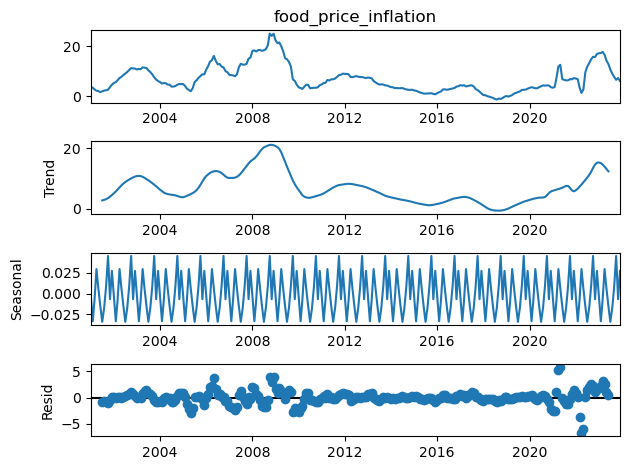

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

prediction_df = prediction_df.set_index("date") # Set date as index for proper labelling
result = seasonal_decompose(prediction_df["food_price_inflation"], model="additive", period=12)

# Plot all components
result.plot()
plt.show()

The decomposition breaks down food price inflation into 4 components: observed food price inflation, trend component, seasonal component and residual component. 

1. Observed food price inflation: this shows actual monthly movements. There are spikes around the 2008 recession and the COVID-19 pandemic. These may indicate structural breaks.
2. Trend component: this is the smoothed long-term movement that removes seasonal fluctuation and short-term noise. The trend changes sharply around 2008 and 2019, which shows that the recession and pandemic changed the inflation process.
3. Seasonal component: this is the most important panel. The repeating waves indicate recurring fluctuations, which shows that food price inflation has a predictable annual seasonal pattern.
4. Residual component: the residuals fluctuate around zero without a clear pattern, which suggests that the additive decomposition adequately captures the underlying trend and seasonal components of food price inflation. However, there are some obvious deviations around 2008 and 2019, which correspond to external shocks and motivate further investigation of structurao breaks.

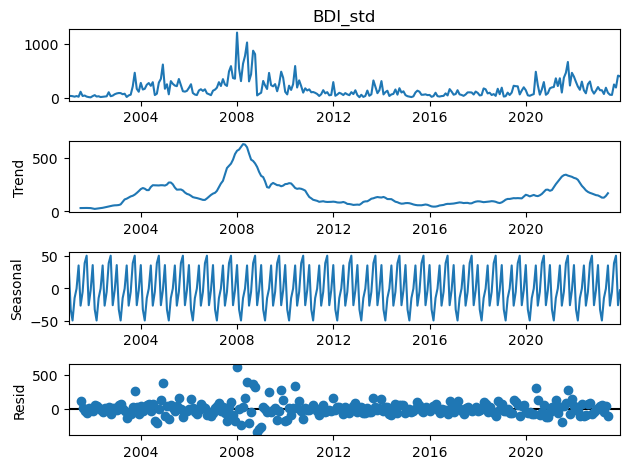

In [12]:
# Check seasonality for BDI standard devviation

result_2 = seasonal_decompose(prediction_df["BDI_std"], model="additive", period=12)

# Plot all components
result_2.plot()
plt.show()

The seasonal decomposition shows similar patterns as the one for food_price_inflation. There are obvious spikes around the 2008 recession and the COVID-19 pandemic. The seasonal component shows repeating waves, which is a sign of seasonality. And the residuals fluctuate around zero with no clear pattern, with some deviation around 2008 and 2020, which might indicate structural breaks.

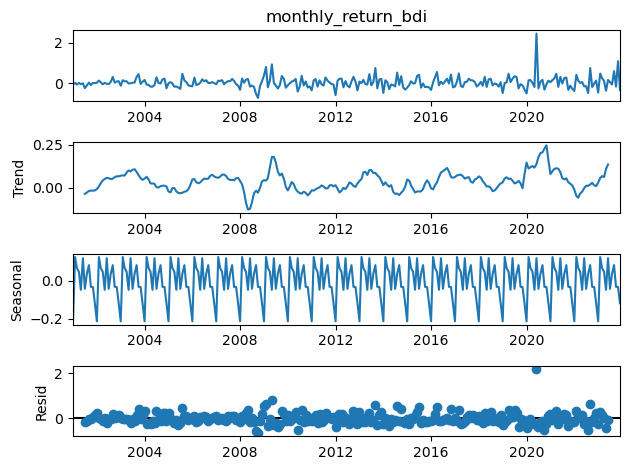

In [13]:
# Check for seasonality of BDI monthly returns

result_3 = seasonal_decompose(prediction_df["monthly_return_bdi"], model="additive", period=12)

# Plot all components
result_3.plot()
plt.show()

The monthly returns also show spikes around 2008 and 2020, which might show structural breaks. There is a repeating wave pattern for the seasonal component, which shows that monthly returns have a predictable annual seasonal pattern. The residuals cluster around zero, with some deviations around 2008 and 2020, motivating the inspection for structural breaks.

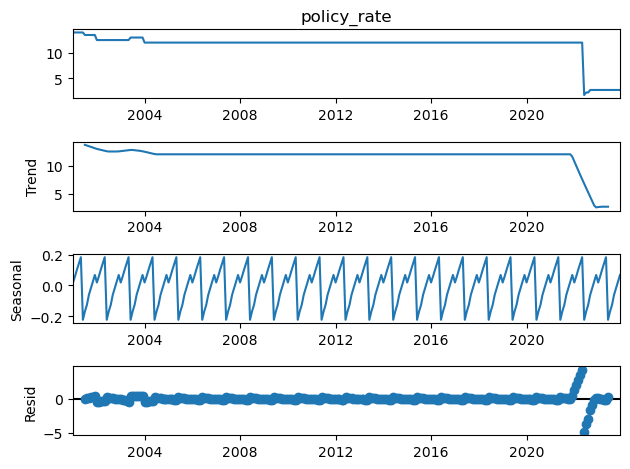

In [14]:
# Check for seasonality of policy_rate

result_4 = seasonal_decompose(prediction_df["policy_rate"], model="additive", period=12)

# Plot all components
result_4.plot()
plt.show()

The seasonal component for the policy rate shows repeating wave patterns despite the policy rate being constant for most of the years. A further investigation of the magnitude of seasonality is needed.

In [15]:
# Magnitude of seasonality
result_4.seasonal.describe()

count    2.760000e+02
mean     1.508455e-19
std      1.199894e-01
min     -2.232008e-01
25%     -7.750947e-02
50%      2.196970e-02
75%      7.623106e-02
max      1.834280e-01
Name: seasonal, dtype: float64

The mean and standard deviation are small, given the typical values of the policy rates, which shows that the seasonality is economically negligible.

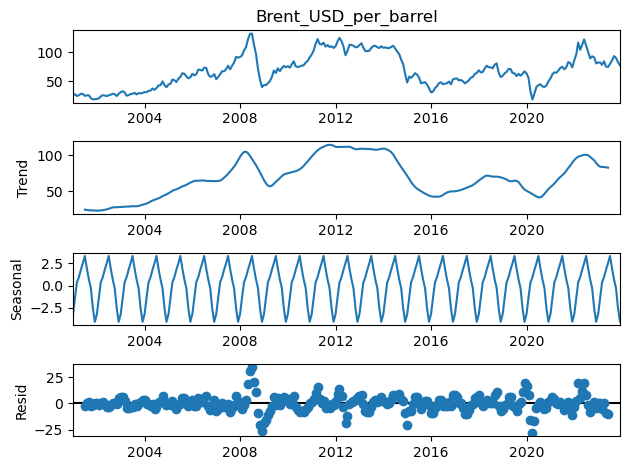

In [16]:
# Check seasonality of Brent crude oil price

result_5 = seasonal_decompose(prediction_df["Brent_USD_per_barrel"], model="additive", period=12)

# Plot all components
result_5.plot()
plt.show()

The Brent crude oil prices show obvious spikes around 2008. There are also slumps around 2014 and the COVID-19 pandemic due to "gluts" or oversupply of oil. The seasonal component shows repeating wave patterns, which shows that oil prices have a predictable annual seasonal pattern. The residuals are clustered around zero with no obvious pattern, with sharp deviations around 2008, 2014 and 2020, which calls for inspection of structural breaks.

### Check structural breaks
Structural breaks are permanent shifts in the underlying statistical properties of a time series, which are typically caused by external shocks. We need to check for them to prevent false conclusions and improve forecasting accuracy.

In [17]:
pip install ruptures

Note: you may need to restart the kernel to use updated packages.


In [18]:
import ruptures as rpt

y = prediction_df["food_price_inflation"].values

# Define the model
model = "l2"  # detects changes in mean

algo = rpt.Binseg(model=model).fit(y)

# Choose number of breaks
breaks = algo.predict(n_bkps=3)

print(breaks)

[80, 105, 260, 276]


In [19]:
# Check break dates
break_dates = prediction_df.index[[b - 1 for b in breaks[:-1]]]

print(break_dates)

DatetimeIndex(['2007-08-01', '2009-09-01', '2022-08-01'], dtype='datetime64[ns]', name='date', freq=None)


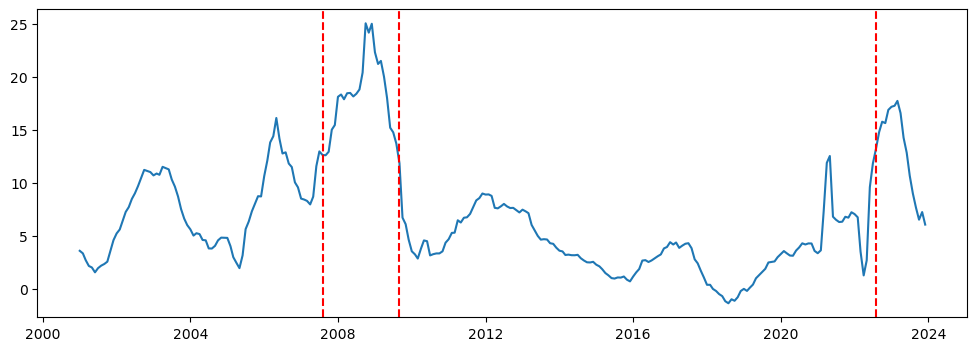

In [20]:
# Plot break dates
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(prediction_df.index, prediction_df["food_price_inflation"])

for b in breaks[:-1]:
    ax.axvline(
        prediction_df.index[b - 1],
        color="red",
        linestyle="--"
    )

plt.show()

The structural breaks in the food_price_inflation are around 2008 and 2022. This suggests that the Russia-Ukraine war of 2022 caused a more permanent shift in food prices than the COVID-19 pandemic.

In [21]:
# Check structural breaks for BDI standard deviation
y2 = prediction_df["BDI_std"].values

# Define the model
model_2 = "rbf"  # detects changes in volatility

algo_2 = rpt.Binseg(model=model_2).fit(y2)

# Choose number of breaks
breaks_2 = algo_2.predict(n_bkps=3)

print(breaks_2)

[30, 120, 220, 276]


In [22]:
# Check break dates
break_dates_2 = prediction_df.index[[b - 1 for b in breaks_2[:-1]]]

print(break_dates_2)

DatetimeIndex(['2003-06-01', '2010-12-01', '2019-04-01'], dtype='datetime64[ns]', name='date', freq=None)


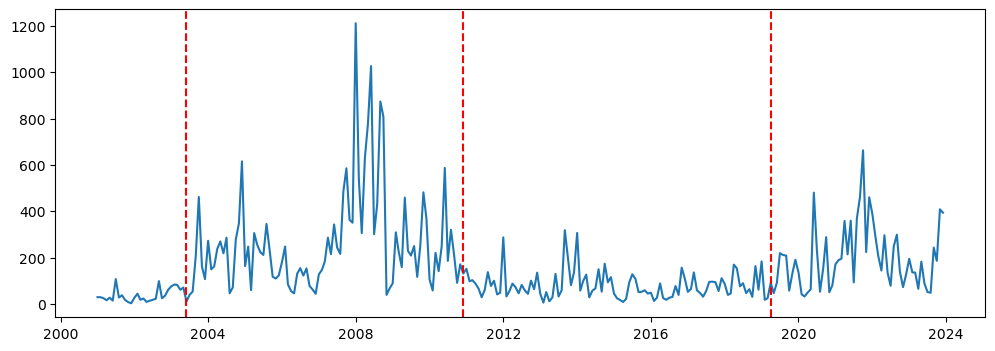

In [23]:
# Plot break dates
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(prediction_df.index, prediction_df["BDI_std"])

for b in breaks_2[:-1]:
    ax.axvline(
        prediction_df.index[b - 1],
        color="red",
        linestyle="--"
    )

plt.show()

There are structural breaks around 2003, 2019, and counterintuitively 2010 instead of 2008. This is because structural breaks detect permanent shifts rather than abrupt spikes.

In [24]:
# Check the structural break for monthly_return_bdi

y3 = prediction_df["monthly_return_bdi"].values

# Define the model
model_3 = "rbf"  # detects changes in volatility

algo_3 = rpt.Binseg(model=model_3).fit(y3)

# Choose number of breaks
breaks_3 = algo_3.predict(n_bkps=3)

print(breaks_3)

[30, 65, 80, 276]


In [25]:
# Check break dates
break_dates_3 = prediction_df.index[[b - 1 for b in breaks_3[:-1]]]

print(break_dates_3)

DatetimeIndex(['2003-06-01', '2006-05-01', '2007-08-01'], dtype='datetime64[ns]', name='date', freq=None)


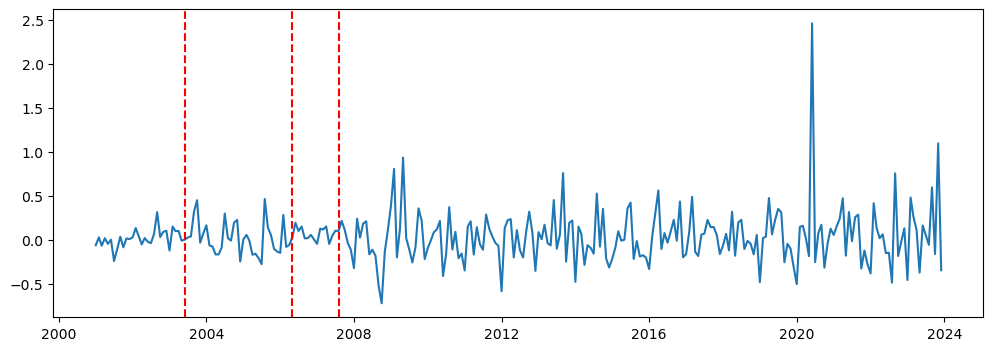

In [26]:
# Plot break dates
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(prediction_df.index, prediction_df["monthly_return_bdi"])

for b in breaks_3[:-1]:
    ax.axvline(
        prediction_df.index[b - 1],
        color="red",
        linestyle="--"
    )

plt.show()

The data shows structural breaks around 2003, 2006 and 2007. The monthly returns are, however, fairly stable.

In [27]:
# Check the structural break for policy_rate

y4 = prediction_df["policy_rate"].values

# Define the model
model_4 = "l2"  # this helps to detect discrete policy changes

algo_4 = rpt.Binseg(model=model_4).fit(y4)

# Choose number of breaks
breaks_4 = algo_4.predict(n_bkps=3)

print(breaks_4)

[35, 255, 260, 276]


In [28]:
# Check break dates
break_dates_4 = prediction_df.index[[b - 1 for b in breaks_4[:-1]]]

print(break_dates_4)

DatetimeIndex(['2003-11-01', '2022-03-01', '2022-08-01'], dtype='datetime64[ns]', name='date', freq=None)


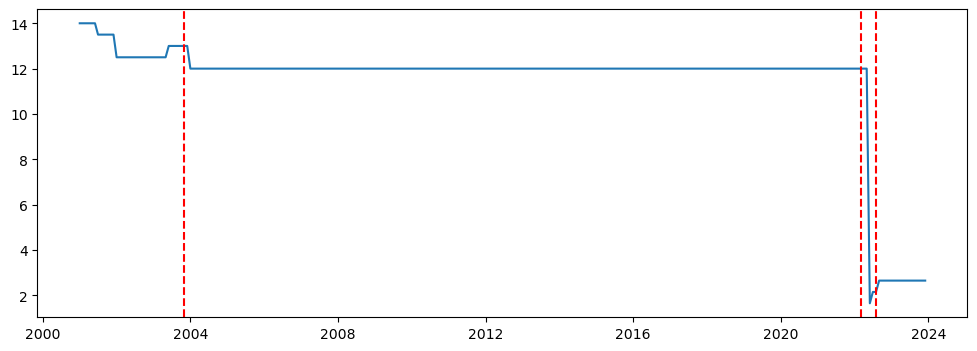

In [29]:
# Plot break dates
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(prediction_df.index, prediction_df["policy_rate"])

for b in breaks_4[:-1]:
    ax.axvline(
        prediction_df.index[b - 1],
        color="red",
        linestyle="--"
    )

plt.show()

The data shows the pattern in the rate chhanging around 2003, 2022 ans 2023. These points could coincide with policy changes.

In [30]:
# Check the structural break for BRENT_USD_per_barrel

y5 = prediction_df["Brent_USD_per_barrel"].values

# Define the model
model_5 = "rbf"  # detects changes in volatility of prices

algo_5 = rpt.Binseg(model=model_5).fit(y5)

# Choose number of breaks
breaks_5 = algo_5.predict(n_bkps=4)

print(breaks_5)

[50, 120, 165, 245, 276]


In [31]:
# Check break dates
break_dates_5 = prediction_df.index[[b - 1 for b in breaks_5[:-1]]]

print(break_dates_5)

DatetimeIndex(['2005-02-01', '2010-12-01', '2014-09-01', '2021-05-01'], dtype='datetime64[ns]', name='date', freq=None)


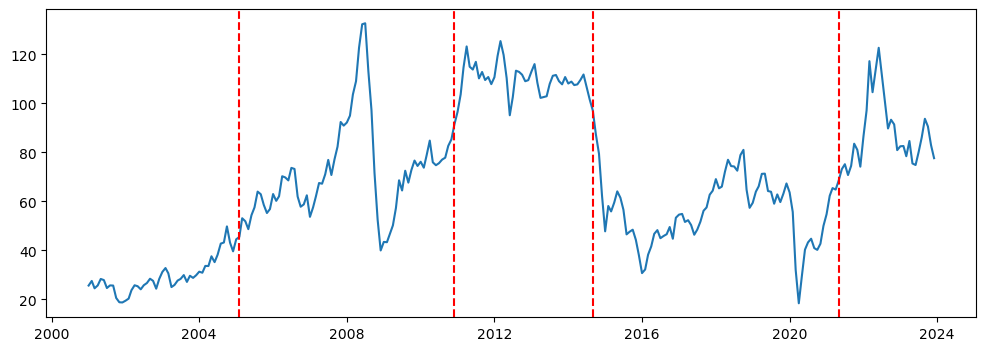

In [32]:
# Plot break dates
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(prediction_df.index, prediction_df["Brent_USD_per_barrel"])

for b in breaks_5[:-1]:
    ax.axvline(
        prediction_df.index[b - 1],
        color="red",
        linestyle="--"
    )

plt.show()

As expected, the crude oil prices changed in volatility around the 2010 oil glut and the COVID-19 pandemic. And the Russia-Ukraine war in 2022.

## Handle Seasonality
Create seasonality dummies, which are binary variables used in prediction to isolate and measure predictable fluctuations in data. The values will be 1 or 0, with 1 indicating that the observation occurs in that month and 0 that it does not occur. We will prevent the dummy variable trap by using (n-1) dummies in order to avoid perfect multicollinearity.

For simplicity, we will let the seasonality dummies for food_price_inflation capture common seasonality.

In [33]:
prediction_df['month'] = prediction_df.index.month

seasonality_month_dummies = pd.get_dummies(
    prediction_df["month"],
    prefix="month",
    drop_first=True
)

In [34]:
seasonality_month_dummies.head()

,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,
2001-01-01,0,0,0,0,0,0,0,0,0,0,0
2001-02-01,1,0,0,0,0,0,0,0,0,0,0
2001-03-01,0,1,0,0,0,0,0,0,0,0,0
2001-04-01,0,0,1,0,0,0,0,0,0,0,0
2001-05-01,0,0,0,1,0,0,0,0,0,0,0


# Handle Structural Breaks
We handle structural breaks by creating structural break dummies. To avoid overfitting and complicating the model, we will only create structural breaks for the dependent variable. The value 0 represents the period before the break and 1 represents after the break.
                                                                                                                                                     We will focus on the years 2007, 2009 and 2022.

In [35]:
prediction_df["break_2007"] = (
    prediction_df.index >= "2007-08-01"
).astype(int)

prediction_df["break_2009"] = (
    prediction_df.index >= "2009-09-01"
).astype(int)

prediction_df["break_2022"] = (
    prediction_df.index >= "2022-08-01"
).astype(int)

In [36]:
prediction_df.head()

,year_month,FAO_23012,FAO_23013,food_price_inflation,BDI_std,first,last,monthly_return_bdi,Brent_USD_per_barrel,policy_rate,month,break_2007,break_2009,break_2022
date,,,,,,,,,,,,,,
2001-01-01,2001-01,34.291207,33.061978,3.602384,29.297289,1599,1504,-0.059412,25.62,14.0,1,0,0,0
2001-02-01,2001-02,34.341562,33.243495,3.359312,29.086577,1493,1537,0.029471,27.50,14.0,2,0,0,0
2001-03-01,2001-03,34.643687,33.295356,2.720000,24.971716,1538,1438,-0.065020,24.50,14.0,3,0,0,0
2001-04-01,2001-04,34.794749,33.321287,2.173337,16.162009,1430,1459,0.020280,25.66,14.0,4,0,0,0
2001-05-01,2001-05,35.273114,33.476873,2.028451,26.959493,1453,1389,-0.044047,28.31,14.0,5,0,0,0


## Test for stationarity
Stationarity is a property of time series data where its statistical properties like mean and variance remain constant over time. If data is non-stationary, its statistical properties change over time, which can lead to misleading relationships and inaccurate predictions. We will carry out the Augmented Dickey-Fuller test while accounting for the structural breaks. Better methods would be Clement-Montane-Reyes or Carrion-i-Silvestre. However, they are difficult to implement in Python.

The ADF is based on the following hypotheses:
Null Hypothesis: the coefficient of the lag = 0, so non-stationary
Alternative hypothesis: the coefficient of the lag < 0, so stationary

If p-value < 0.05, reject the null, so the series is stationary.
If p-value > 0.05, fail to reject the null, so series is non-stationary

In [37]:
# Test for stationarity of food_price_inflation
import statsmodels.api as sm

prediction_df["lag1"] = prediction_df["food_price_inflation"].shift(1) # this represents the lagged value of the target time series. 
#It's important to include because ADF asks if the previous value of the series help explain the change in the series.

prediction_df["diff"] = prediction_df["food_price_inflation"].diff()

prediction_df["diff_lag1"] = prediction_df["diff"].shift(1)

X = prediction_df[
[
"lag1",
"diff_lag1",
"break_2007",
"break_2009",
"break_2022"
]
]

X = sm.add_constant(X)

y = prediction_df["diff"]

model = sm.OLS(
    y,
    X,
    missing="drop"
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   diff   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     15.86
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           1.10e-13
Time:                        13:16:20   Log-Likelihood:                -385.15
No. Observations:                 274   AIC:                             782.3
Df Residuals:                     268   BIC:                             804.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6449      0.180      3.584      0.0

The p-value for the coefficient of lag1 is less than 0.05, so the series is stationary.

In [38]:
# Test for stationarity of BDI_std

# First create temporary structural break dummy variables for BDI_std, as they will not be used in the final prediction model

prediction_df["temp_break_2003"] = (
    prediction_df.index >= "2003-06-01"
).astype(int)

prediction_df["temp_break_2010"] = (
    prediction_df.index >= "2010-12-01"
).astype(int)

prediction_df["temp_break_2019"] = (
    prediction_df.index >= "2019-04-01"
).astype(int)

# Create lags for the independent variable
prediction_df["temp_lag"] = prediction_df["BDI_std"].shift(1) # this represents the lagged value of the BDI_std. 
#It's important to include because ADF asks if the previous value of the series help explain the change in the series.

prediction_df["temp_diff"] = prediction_df["BDI_std"].diff()

prediction_df["temp_diff_lag"] = prediction_df["temp_diff"].shift(1)

X2 = prediction_df[
[
"temp_lag",
"temp_diff_lag",
"temp_break_2003",
"temp_break_2010",
"temp_break_2019"
]
]

X2 = sm.add_constant(X2)

y2 = prediction_df["temp_diff"]

model2 = sm.OLS(
    y2,
    X2,
    missing="drop"
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              temp_diff   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     20.95
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           1.15e-17
Time:                        13:16:20   Log-Likelihood:                -1720.9
No. Observations:                 274   AIC:                             3454.
Df Residuals:                     268   BIC:                             3476.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              21.7148     25.266     

The p-value of the coefficient of temp_lag for BDI_std is less than 0.05, so reject the null. Therefore, the BDI_std series is stationary.

In [39]:
# Drop the temp variables to avoid overcrowding the dataframe

prediction_df = prediction_df.drop(columns=['temp_lag', 'temp_diff', 'temp_diff_lag', 'temp_break_2003', 'temp_break_2010', 'temp_break_2019'])

In [40]:
# Test for stationarity of monthly_return_bdi

# First create temporary structural break dummy variables for monthly_return_bdi, as they will not be used in the final prediction model

prediction_df["temp_break_2003"] = (
    prediction_df.index >= "2003-06-01"
).astype(int)

prediction_df["temp_break_2006"] = (
    prediction_df.index >= "2006-05-01"
).astype(int)

prediction_df["temp_break_2007"] = (
    prediction_df.index >= "2007-08-01"
).astype(int)

# Create lags for the independent variable
prediction_df["temp_lag"] = prediction_df["monthly_return_bdi"].shift(1) # this represents the lagged value of monthly_return_bdi. 
#It's important to include because ADF asks if the previous value of the series help explain the change in the series.

prediction_df["temp_diff"] = prediction_df["monthly_return_bdi"].diff()

prediction_df["temp_diff_lag"] = prediction_df["temp_diff"].shift(1)

X3 = prediction_df[
[
"temp_lag",
"temp_diff_lag",
"temp_break_2003",
"temp_break_2006",
"temp_break_2007"
]
]

X3 = sm.add_constant(X3)

y3 = prediction_df["temp_diff"]

model3 = sm.OLS(
    y3,
    X3,
    missing="drop"
).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:              temp_diff   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.526
Method:                 Least Squares   F-statistic:                     61.57
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           1.43e-42
Time:                        13:16:20   Log-Likelihood:                -42.961
No. Observations:                 274   AIC:                             97.92
Df Residuals:                     268   BIC:                             119.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0208      0.055     

The p-value of the coefficient of temp_lag for monthly_return_bdi is less than 0.05, so reject the null. Therefore the monthly_return_bdi is stationary.

In [41]:
# Drop the temp variables to avoid overcrowding the dataframe

prediction_df = prediction_df.drop(columns=['temp_lag', 'temp_diff', 'temp_diff_lag', 'temp_break_2003', 'temp_break_2006', 'temp_break_2007'])

In [42]:
# Test for stationarity of policy_rate

# First create temporary structural break dummy variables for policy_rate, as they will not be used in the final prediction model

prediction_df["temp_break_2003"] = (
    prediction_df.index >= "2003-11-01"
).astype(int)

prediction_df["temp_break_2022"] = (
    prediction_df.index >= "2022-03-01"
).astype(int)

prediction_df["temp_break_2022_2"] = (
    prediction_df.index >= "2022-08-01"
).astype(int)

# Create lags for the independent variable
prediction_df["temp_lag"] = prediction_df["policy_rate"].shift(1) # this represents the lagged value of the independent variable. 
#It's important to include because ADF asks if the previous value of the series help explain the change in the series.

prediction_df["temp_diff"] = prediction_df["policy_rate"].diff()

prediction_df["temp_diff_lag"] = prediction_df["temp_diff"].shift(1)

X4 = prediction_df[
[
"temp_lag",
"temp_diff_lag",
"temp_break_2003",
"temp_break_2022",
"temp_break_2022_2"
]
]

X4 = sm.add_constant(X4)

y4 = prediction_df["temp_diff"]

model4 = sm.OLS(
    y4,
    X4,
    missing="drop"
).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:              temp_diff   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     17.53
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           5.15e-15
Time:                        13:16:20   Log-Likelihood:                -224.57
No. Observations:                 274   AIC:                             461.1
Df Residuals:                     268   BIC:                             482.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.4566      1.76

The p-value for the coefficient of temp_lag for policy_rate is greater than 0.05, so the policy_rate series is non-stationary as you fail to reject the null hypothesis. Since the policy rate remains constant for long periods and only changes when adjusted, an ADF test can be difficult to interpret. It also does not necessarily call for transformation of the variable. The policy rate will be retained in levels because its economic interpretation as a monetary policy stance is more meaningful than its first difference.

In [43]:
# Drop the temp variables to avoid overcrowding the dataframe

prediction_df = prediction_df.drop(columns=['temp_lag', 'temp_diff', 'temp_diff_lag', 'temp_break_2003', 'temp_break_2022', 'temp_break_2022_2'])

In [44]:
# Test for stationarity of Brent_USD_per_barrel

# First create temporary structural break dummy variables for Brent_USD_per_barrel, as they will not be used in the final prediction model

prediction_df["temp_break_2005"] = (
    prediction_df.index >= "2005-02-01"
).astype(int)

prediction_df["temp_break_2010"] = (
    prediction_df.index >= "2010-12-01"
).astype(int)

prediction_df["temp_break_2014"] = (
    prediction_df.index >= "2014-09-01"
).astype(int)

prediction_df["temp_break_2021"] = (
    prediction_df.index >= "2021-05-01"
).astype(int)

# Create lags for the independent variable
prediction_df["temp_lag"] = prediction_df["Brent_USD_per_barrel"].shift(1) # this represents the lagged value of the independent variable. 
#It's important to include because ADF asks if the previous value of the series help explain the change in the series.

prediction_df["temp_diff"] = prediction_df["Brent_USD_per_barrel"].diff()

prediction_df["temp_diff_lag"] = prediction_df["temp_diff"].shift(1)

X5 = prediction_df[
[
"temp_lag",
"temp_diff_lag",
"temp_break_2005",
"temp_break_2010",
"temp_break_2014",
"temp_break_2021"
]
]

X5 = sm.add_constant(X5)

y5 = prediction_df["temp_diff"]

model5 = sm.OLS(
    y5,
    X5,
    missing="drop"
).fit()

print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:              temp_diff   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     12.17
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           4.25e-12
Time:                        13:16:20   Log-Likelihood:                -857.44
No. Observations:                 274   AIC:                             1729.
Df Residuals:                     267   BIC:                             1754.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.5070      1.076     

The p-value of the coefficient of temp_lag for Brent crude oil prices is less than 0.05, so reject the null hypothesis. Therefore, the Brent crude oil price series is stationary.

In [45]:
# Drop the temp variables to avoid overcrowding the dataframe

prediction_df = prediction_df.drop(columns=['temp_lag', 'temp_diff', 'temp_diff_lag', 'temp_break_2005', 'temp_break_2010', 'temp_break_2014', 'temp_break_2021'])

## Correlation
As an exploratory, step, we will also examine the Pearson correlation coefficient. We will not be including the seasonality and structural break dummies as they are more for the prediction model in the later stage.

In [46]:
corr = prediction_df[
    [
        "food_price_inflation",
        "BDI_std",
        "monthly_return_bdi",
        "Brent_USD_per_barrel",
        "policy_rate"
    ]
].corr(method="pearson")

print(corr)

                      food_price_inflation   BDI_std  monthly_return_bdi  \
food_price_inflation              1.000000  0.388723            0.014618   
BDI_std                           0.388723  1.000000            0.023734   
monthly_return_bdi                0.014618  0.023734            1.000000   
Brent_USD_per_barrel              0.171738  0.233649           -0.047978   
policy_rate                      -0.299173 -0.048810           -0.030464   

                      Brent_USD_per_barrel  policy_rate  
food_price_inflation              0.171738    -0.299173  
BDI_std                           0.233649    -0.048810  
monthly_return_bdi               -0.047978    -0.030464  
Brent_USD_per_barrel              1.000000    -0.271631  
policy_rate                      -0.271631     1.000000  


At first glance, the food_price_inflation has a positive relationship with BDI_std, monthly_return_bdi and Brent_USD_per_barrel. However, the coefficients are small, suggesting weak relationships. The food price inflation has a negative relationship with policy_rate, which makes sense as higher interest rates are expected to lower consumer prices.

## Cross-correlation Function
We compute the cross-correlation function to determine the lag structures. The CCF assumes that the series are stationary. We will first pre-whiten to remove autocorelation and some seasonality. 

C:\Users\Gorata\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


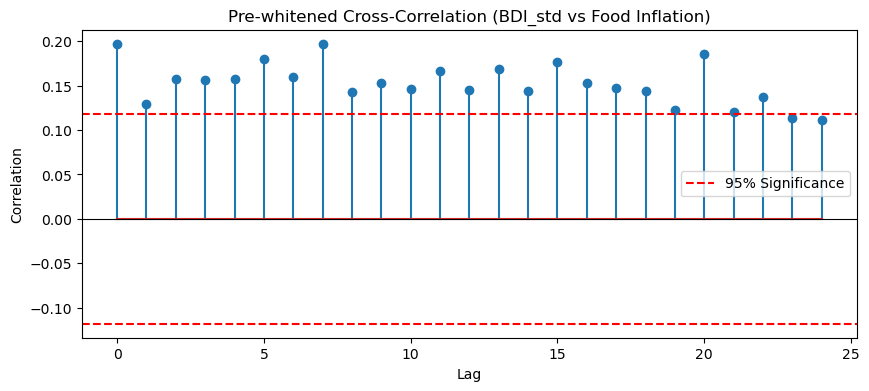

In [47]:
# Plot pre-whitened CCF for BDI_std and food_price_inflation

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import ccf

# Fit an AR model on BDI_std (X) to "whiten" it
# 'lags=1' or 'lags=2' is usually enough to remove the trend/memory
model = AutoReg(prediction_df['BDI_std'], lags=1).fit()

# Get the whitened X (the residuals where memory is removed)
x_whitened = model.resid

# Filter Food Inflation (Y) using the same AR parameters
# Filter Y using the lag coefficient from X's model
params = model.params
y_whitened = prediction_df['food_price_inflation'] - params['const'] - params['BDI_std.L1'] * prediction_df['food_price_inflation'].shift(1)

# Drop NaN values created by shifting
valid_idx = x_whitened.dropna().index.intersection(y_whitened.dropna().index)
x_clean = x_whitened.loc[valid_idx]
y_clean = y_whitened.loc[valid_idx]

# Plot the Cleaned CCF
cross_corr = ccf(x_clean, y_clean, adjusted=False)[:25] # First 25 lags

plt.figure(figsize=(10, 4))
plt.stem(range(len(cross_corr)), cross_corr)
plt.axhline(0, color='black', linewidth=0.8)

# Add 95% Confidence Interval lines!
n = len(x_clean)
plt.axhline(1.96 / np.sqrt(n), color='red', linestyle='--', label='95% Significance')
plt.axhline(-1.96 / np.sqrt(n), color='red', linestyle='--')

plt.title("Pre-whitened Cross-Correlation (BDI_std vs Food Inflation)")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()
plt.show()

Lag 0, 7 and 20 show strong peaks.

C:\Users\Gorata\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


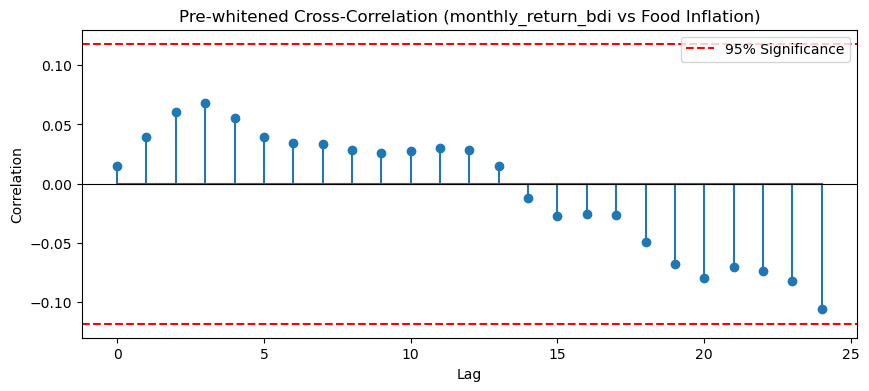

In [48]:
# Plot pre-whitened CCF for monthly_return_bdi and food_price_inflation

# Fit an AR model on monthly_return_bdi (X) to "whiten" it
# 'lags=1' or 'lags=2' is usually enough to remove the trend/memory
model = AutoReg(prediction_df['monthly_return_bdi'], lags=1).fit()

# Get the whitened X (the residuals where memory is removed)
x_whitened = model.resid

# Filter Food Inflation (Y) using the same AR parameters
# Filter Y using the lag coefficient from X's model
params = model.params
y_whitened = prediction_df['food_price_inflation'] - params['const'] - params['monthly_return_bdi.L1'] * prediction_df['food_price_inflation'].shift(1)

# Drop NaN values created by shifting
valid_idx = x_whitened.dropna().index.intersection(y_whitened.dropna().index)
x_clean = x_whitened.loc[valid_idx]
y_clean = y_whitened.loc[valid_idx]

# Plot the Cleaned CCF
cross_corr = ccf(x_clean, y_clean, adjusted=False)[:25] # First 25 lags

plt.figure(figsize=(10, 4))
plt.stem(range(len(cross_corr)), cross_corr)
plt.axhline(0, color='black', linewidth=0.8)

# Add 95% Confidence Interval lines!
n = len(x_clean)
plt.axhline(1.96 / np.sqrt(n), color='red', linestyle='--', label='95% Significance')
plt.axhline(-1.96 / np.sqrt(n), color='red', linestyle='--')

plt.title("Pre-whitened Cross-Correlation (monthly_return_bdi vs Food Inflation)")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()
plt.show()

No significant lags.

C:\Users\Gorata\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


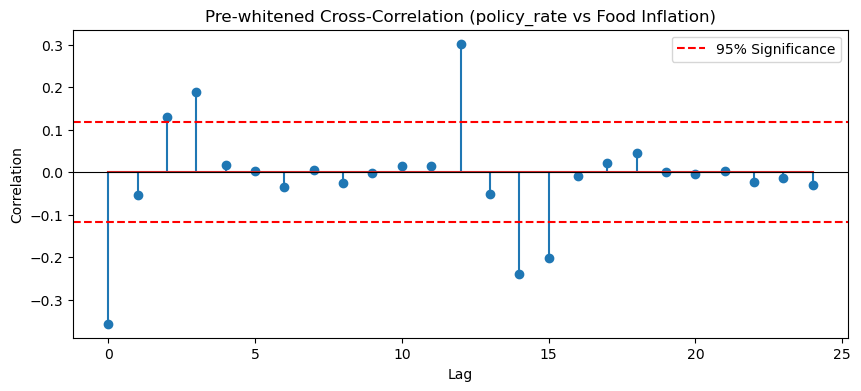

In [49]:
# Plot pre-whitened CCF for policy_rate and food_price_inflation

# Fit an AR model on policy_rate (X) to "whiten" it
# 'lags=1' or 'lags=2' is usually enough to remove the trend/memory
model = AutoReg(prediction_df['policy_rate'], lags=1).fit()

# Get the whitened X (the residuals where memory is removed)
x_whitened = model.resid

# Filter Food Inflation (Y) using the same AR parameters
# Filter Y using the lag coefficient from X's model
params = model.params
y_whitened = prediction_df['food_price_inflation'] - params['const'] - params['policy_rate.L1'] * prediction_df['food_price_inflation'].shift(1)

# Drop NaN values created by shifting
valid_idx = x_whitened.dropna().index.intersection(y_whitened.dropna().index)
x_clean = x_whitened.loc[valid_idx]
y_clean = y_whitened.loc[valid_idx]

# Plot the Cleaned CCF
cross_corr = ccf(x_clean, y_clean, adjusted=False)[:25] # First 25 lags

plt.figure(figsize=(10, 4))
plt.stem(range(len(cross_corr)), cross_corr)
plt.axhline(0, color='black', linewidth=0.8)

# Add 95% Confidence Interval lines!
n = len(x_clean)
plt.axhline(1.96 / np.sqrt(n), color='red', linestyle='--', label='95% Significance')
plt.axhline(-1.96 / np.sqrt(n), color='red', linestyle='--')

plt.title("Pre-whitened Cross-Correlation (policy_rate vs Food Inflation)")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()


There are significant and sharp spikes at lag 0 and lag 12.

C:\Users\Gorata\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


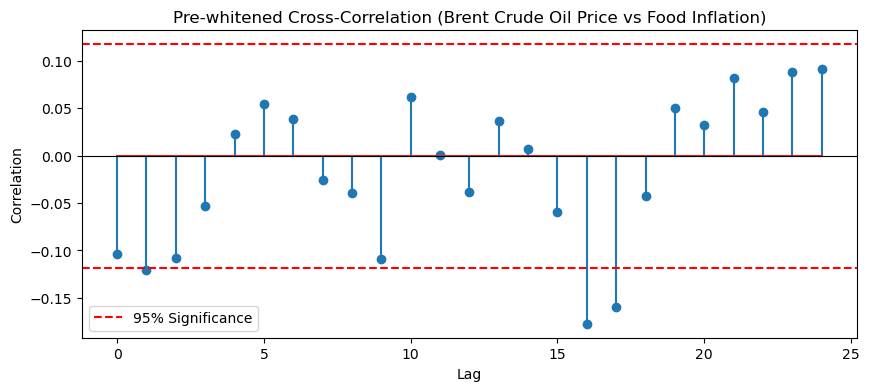

In [50]:
# Plot pre-whitened CCF for Brent_USD_per_barrel and food_price_inflation

# Fit an AR model on Brent_USD_per_barrel (X) to "whiten" it
# 'lags=1' or 'lags=2' is usually enough to remove the trend/memory
model = AutoReg(prediction_df['Brent_USD_per_barrel'], lags=1).fit()

# Get the whitened X (the residuals where memory is removed)
x_whitened = model.resid

# Filter Food Inflation (Y) using the same AR parameters
# Filter Y using the lag coefficient from X's model
params = model.params
y_whitened = prediction_df['food_price_inflation'] - params['const'] - params['Brent_USD_per_barrel.L1'] * prediction_df['food_price_inflation'].shift(1)

# Drop NaN values created by shifting
valid_idx = x_whitened.dropna().index.intersection(y_whitened.dropna().index)
x_clean = x_whitened.loc[valid_idx]
y_clean = y_whitened.loc[valid_idx]

# Plot the Cleaned CCF
cross_corr = ccf(x_clean, y_clean, adjusted=False)[:25] # First 25 lags

plt.figure(figsize=(10, 4))
plt.stem(range(len(cross_corr)), cross_corr)
plt.axhline(0, color='black', linewidth=0.8)

# Add 95% Confidence Interval lines!
n = len(x_clean)
plt.axhline(1.96 / np.sqrt(n), color='red', linestyle='--', label='95% Significance')
plt.axhline(-1.96 / np.sqrt(n), color='red', linestyle='--')

plt.title("Pre-whitened Cross-Correlation (Brent Crude Oil Price vs Food Inflation)")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()


There are significant dips at lags 16 and 17. This is longer than expected for oil prices to affect food inflation but it might make sense if the economy was shielded by prudent monetary policy.

## Create Lagged Predictors
After determining the lags, we will create lagged predictors and include them in the model. Instead of using all lags, we will choose the strongest non-zero lags for each variable. We will use ARIMAX due to the presence of lags.

In [51]:
# Lags for BDI_std
prediction_df["BDI_std_lag7"] = prediction_df["BDI_std"].shift(7)

# Lags for policy_rate
prediction_df["policy_rate_lag12"] = prediction_df["policy_rate"].shift(12)

# Lags for Brent crude oil prices
prediction_df["Brent_lag16"] = prediction_df["Brent_USD_per_barrel"].shift(16)

In [52]:
prediction_df.head()

,year_month,FAO_23012,FAO_23013,food_price_inflation,BDI_std,first,last,monthly_return_bdi,Brent_USD_per_barrel,policy_rate,month,break_2007,break_2009,break_2022,lag1,diff,diff_lag1,BDI_std_lag7,policy_rate_lag12,Brent_lag16
date,,,,,,,,,,,,,,,,,,,,
2001-01-01,2001-01,34.291207,33.061978,3.602384,29.297289,1599,1504,-0.059412,25.62,14.0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2001-02-01,2001-02,34.341562,33.243495,3.359312,29.086577,1493,1537,0.029471,27.50,14.0,2,0,0,0,3.602384,-0.243072,NaN,NaN,NaN,NaN
2001-03-01,2001-03,34.643687,33.295356,2.720000,24.971716,1538,1438,-0.065020,24.50,14.0,3,0,0,0,3.359312,-0.639312,-0.243072,NaN,NaN,NaN
2001-04-01,2001-04,34.794749,33.321287,2.173337,16.162009,1430,1459,0.020280,25.66,14.0,4,0,0,0,2.720000,-0.546663,-0.639312,NaN,NaN,NaN
2001-05-01,2001-05,35.273114,33.476873,2.028451,26.959493,1453,1389,-0.044047,28.31,14.0,5,0,0,0,2.173337,-0.144886,-0.546663,NaN,NaN,NaN


## Granger Causality Test
We also carry out the Granger Causality test to see if past values of the indepedent variables are useful in forecasting the future values of the dependent variable. It is different from CCF because while CCF helps determine which lags to test, Granger Causality tests whether lagged relationships are statistically useful.

In [53]:
from statsmodels.tsa.stattools import grangercausalitytests

# Define the dependent variable
dependent_var = 'food_price_inflation'

# Define the independent variables to test
independent_vars = ['BDI_std', 'monthly_return_bdi', 'policy_rate', 'Brent_USD_per_barrel']

# Determine the maximum number of lags to test. We expect longer lag lengths due to the Botswana goverment's prudent policies to shield
# the economy

max_lags = 24

print(f"Performing Granger Causality Tests (maxlags={max_lags}):\n")

for ind_var in independent_vars:
    print(f"--- Testing if {ind_var} Granger-causes {dependent_var} ---")
    # Combine the dependent and independent variables for the test
    data_for_test = prediction_df[[dependent_var, ind_var]].dropna()

    # Perform the Granger Causality test
    # output=False suppresses the verbose output, only returns results dictionary
    granger_results = grangercausalitytests(data_for_test, maxlag=max_lags, verbose=False)

    # Interpret results for each lag
    for lag in range(1, max_lags + 1):
        test_results = granger_results[lag]
        # We usually look at the F-statistic p-value (test 'ssr_ftest')
        p_value = test_results[0]['ssr_ftest'][1]
        print(f"  Lag {lag}: p-value = {p_value:.4f}")
        if p_value < 0.05:
            print(f"    (Reject H0: {ind_var} Granger-causes {dependent_var} at 5% significance level)")
        else:
            print(f"    (Fail to reject H0: {ind_var} does not Granger-cause {dependent_var} at 5% significance level)")
    print("\n")

Performing Granger Causality Tests (maxlags=24):

--- Testing if BDI_std Granger-causes food_price_inflation ---
  Lag 1: p-value = 0.0209
    (Reject H0: BDI_std Granger-causes food_price_inflation at 5% significance level)
  Lag 2: p-value = 0.2386
    (Fail to reject H0: BDI_std does not Granger-cause food_price_inflation at 5% significance level)
  Lag 3: p-value = 0.3476
    (Fail to reject H0: BDI_std does not Granger-cause food_price_inflation at 5% significance level)
  Lag 4: p-value = 0.2998
    (Fail to reject H0: BDI_std does not Granger-cause food_price_inflation at 5% significance level)
  Lag 5: p-value = 0.3475
    (Fail to reject H0: BDI_std does not Granger-cause food_price_inflation at 5% significance level)
  Lag 6: p-value = 0.0346
    (Reject H0: BDI_std Granger-causes food_price_inflation at 5% significance level)
  Lag 7: p-value = 0.0420
    (Reject H0: BDI_std Granger-causes food_price_inflation at 5% significance level)
  Lag 8: p-value = 0.0123
    (Reject H

Result interpretation:
1. BDI_std starts to Granger cause food price inflation at lag 6.
2. monthly_return_bdi does not Granger cause food price inflation at any of the lags.
3. policy_rate starts to Granger causes food price inflation at lag 13.
4. Brent_USD_per_barrel starts to Granger cause food price inflation at lag 17.

These results are consistent with the lags we determined using Cross Correlation Function plots, so we can be confident that we will get reliable predictions using the selected lags. We will exclude the monthly_return_bdi from the model since there are no significant lags in the CCF and it does not Granger cause food price inflation at any lag.

## Check for Multicollinearity
Multicollinearity is when two or more imput variables in a regression model are closely related, which affects model reliability. Before modelling, we will check that are variables do not exhibit any multicollinearity. We already eliminated multicollinerity in the seasonality dummy variables by using (n-1) dummies.

In [54]:
# First look at correlation matrix

# Create exogenous dataframe. But before that, combine the seasonality dummies with the main dataframe in a new dataframe called model_df
model_df = prediction_df.merge(
    seasonality_month_dummies,
    on="date",
    how="left"
)

In [55]:
model_df.head()

,year_month,FAO_23012,FAO_23013,food_price_inflation,BDI_std,first,last,monthly_return_bdi,Brent_USD_per_barrel,policy_rate,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,2001-01,34.291207,33.061978,3.602384,29.297289,1599,1504,-0.059412,25.62,14.0,...,0,0,0,0,0,0,0,0,0,0
2001-02-01,2001-02,34.341562,33.243495,3.359312,29.086577,1493,1537,0.029471,27.50,14.0,...,0,0,0,0,0,0,0,0,0,0
2001-03-01,2001-03,34.643687,33.295356,2.720000,24.971716,1538,1438,-0.065020,24.50,14.0,...,1,0,0,0,0,0,0,0,0,0
2001-04-01,2001-04,34.794749,33.321287,2.173337,16.162009,1430,1459,0.020280,25.66,14.0,...,0,1,0,0,0,0,0,0,0,0
2001-05-01,2001-05,35.273114,33.476873,2.028451,26.959493,1453,1389,-0.044047,28.31,14.0,...,0,0,1,0,0,0,0,0,0,0


In [56]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 276 entries, 2001-01-01 to 2023-12-01
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year_month            276 non-null    object 
 1   FAO_23012             276 non-null    float64
 2   FAO_23013             276 non-null    float64
 3   food_price_inflation  276 non-null    float64
 4   BDI_std               276 non-null    float64
 5   first                 276 non-null    int64  
 6   last                  276 non-null    int64  
 7   monthly_return_bdi    276 non-null    float64
 8   Brent_USD_per_barrel  276 non-null    float64
 9   policy_rate           276 non-null    float64
 10  month                 276 non-null    int64  
 11  break_2007            276 non-null    int32  
 12  break_2009            276 non-null    int32  
 13  break_2022            276 non-null    int32  
 14  lag1                  275 non-null    float64
 15  diff

In [57]:
# Select the variables to use for the final model
model_df = model_df[
    [
        "year_month",
        "food_price_inflation",
        "BDI_std",
        "BDI_std_lag7",
        "policy_rate",
        "policy_rate_lag12",
        "Brent_lag16",
        "month_2",
        "month_3",
        "month_4",
        "month_5",
        "month_6",
        "month_7",
        "month_8",
        "month_9",
        "month_10",
        "month_11",
        "month_12",
        "break_2007",
        "break_2009",
        "break_2022"
    ]
]

In [58]:
# Drop missing values as they will not be useful for the prediction
model_df = model_df.dropna()

In [59]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 260 entries, 2002-05-01 to 2023-12-01
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year_month            260 non-null    object 
 1   food_price_inflation  260 non-null    float64
 2   BDI_std               260 non-null    float64
 3   BDI_std_lag7          260 non-null    float64
 4   policy_rate           260 non-null    float64
 5   policy_rate_lag12     260 non-null    float64
 6   Brent_lag16           260 non-null    float64
 7   month_2               260 non-null    uint8  
 8   month_3               260 non-null    uint8  
 9   month_4               260 non-null    uint8  
 10  month_5               260 non-null    uint8  
 11  month_6               260 non-null    uint8  
 12  month_7               260 non-null    uint8  
 13  month_8               260 non-null    uint8  
 14  month_9               260 non-null    uint8  
 15  mont

In [60]:
# Create exogenous dataframe
X = model_df.drop(
    columns=["food_price_inflation", "year_month"]
)

In [61]:
# As a first step to testing for multicollinearity, check correlation matrix
corr = X.corr()

print(corr.round(2))

                   BDI_std  BDI_std_lag7  policy_rate  policy_rate_lag12  \
BDI_std               1.00          0.38        -0.01              -0.05   
BDI_std_lag7          0.38          1.00        -0.08              -0.00   
policy_rate          -0.01         -0.08         1.00               0.59   
policy_rate_lag12    -0.05         -0.00         0.59               1.00   
Brent_lag16          -0.10         -0.01        -0.22              -0.33   
month_2              -0.06         -0.05         0.03               0.04   
month_3              -0.09         -0.00         0.03               0.04   
month_4              -0.03          0.08         0.03               0.04   
month_5              -0.01          0.09         0.03               0.05   
month_6               0.06         -0.05        -0.02              -0.03   
month_7              -0.07         -0.01        -0.02              -0.03   
month_8              -0.02          0.06        -0.02              -0.03   
month_9     

Correlation is generally low between most variables. However, break_2022 is highly correlated with policy_rate (0.93) and break_2007 is highly correlated with break_2009 (0.79).

### Variance Inflation Factor (VIF)
This is the standard test for calculating multicollinearity. VIF < 5 is generally acceptable, VIF of 5 - 10 shows moderate multicollinearity, and VIF greater than 10 shows serious multicollinearity [(Source, Datacamp)](https://www.datacamp.com/tutorial/variance-inflation-factor).

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

             Variable        VIF
0             BDI_std   3.056546
1        BDI_std_lag7   2.822471
2         policy_rate  73.629789
3   policy_rate_lag12  65.076781
4         Brent_lag16  10.503693
5             month_2   1.982871
6             month_3   1.986149
7             month_4   1.971136
8             month_5   2.018812
9             month_6   1.952823
10            month_7   1.958260
11            month_8   2.016761
12            month_9   2.025290
13           month_10   2.039799
14           month_11   2.020243
15           month_12   2.011413
16         break_2007  19.931798
17         break_2009  13.096651
18         break_2022   2.809701


Result Interpretation
1. Most variables show acceptable of mutlicollinearity (<5) and are retained in the model.
2. Brent_lag16 shows a VIF slightly above the commonly used threshold (VIF = 10.50). However, we retain it because it is supported by the cross-correlation and Granger causality analyses and has a strong theoretical justification as a determinant of food price inflation. We will further assess its effect through the ARIMAX model diagnostics.
3. policy_rate and policy_rate_lag12 show extremely high levels of multicollinearity. Since monetary policy is generally expected to influence inflation with a lag rather than immediately, we exclude policy_rate from the model, while we retain policy_rate_lag12.
4. break_2007 and break_2009 also show moderately high levels of multicollinearity. As both are step dummies representing the same structural event (the 2008 global financial crisis), including both would introduce redundant information. Therefore, we only retain break_2009 in the final model, while we exclude break_2007.

In [65]:
# Drop vaiables showing high multicollinearity
X = X.drop(
    columns=["policy_rate", "break_2007"]
)

In [66]:
X.head()

,BDI_std,BDI_std_lag7,policy_rate_lag12,Brent_lag16,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,break_2009,break_2022
date,,,,,,,,,,,,,,,,,
2002-05-01,8.906440,17.054667,14.0,25.62,0,0,0,1,0,0,0,0,0,0,0,0,0
2002-06-01,13.764713,7.987680,14.0,27.50,0,0,0,0,1,0,0,0,0,0,0,0,0
2002-07-01,17.768271,2.963007,13.5,24.50,0,0,0,0,0,1,0,0,0,0,0,0,0
2002-08-01,22.407375,26.682233,13.5,25.66,0,0,0,0,0,0,1,0,0,0,0,0,0
2002-09-01,98.619712,44.386431,13.5,28.31,0,0,0,0,0,0,0,1,0,0,0,0,0


In [67]:
model_df = model_df.drop(columns = ["policy_rate", "break_2007"])

In [68]:
model_df.head()

,year_month,food_price_inflation,BDI_std,BDI_std_lag7,policy_rate_lag12,Brent_lag16,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,break_2009,break_2022
date,,,,,,,,,,,,,,,,,,,
2002-05-01,2002-05,7.724501,8.906440,17.054667,14.0,25.62,0,0,0,1,0,0,0,0,0,0,0,0,0
2002-06-01,2002-06,8.503680,13.764713,7.987680,14.0,27.50,0,0,0,0,1,0,0,0,0,0,0,0,0
2002-07-01,2002-07,9.027878,17.768271,2.963007,13.5,24.50,0,0,0,0,0,1,0,0,0,0,0,0,0
2002-08-01,2002-08,9.716459,22.407375,26.682233,13.5,25.66,0,0,0,0,0,0,1,0,0,0,0,0,0
2002-09-01,2002-09,10.486601,98.619712,44.386431,13.5,28.31,0,0,0,0,0,0,0,1,0,0,0,0,0


# Model Fitting and Diagnostics
Fit the final model. We first determine the ARIMA order, ARIMA(p,d,q) of food_price_inflation. Where:
- p = autoregressive terms (past food inflation values)
- d = differencing order (stationarity)
- q = moving average terms (past errors)

Because of the existence of structural breaks, we will not be using the standard ACF and PACF plots to determine the ARIMA order. We will instead use SARIMAX to select order using AIC/BIC.

In [69]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings
warnings.filterwarnings("ignore")


p = range(0, 4)
d = range(0, 2)
q = range(0, 4)

best_aic = float("inf")
best_order = None
best_model = None

for order in itertools.product(p, d, q):

    try:
        model = SARIMAX(
            model_df['food_price_inflation'],
            exog=X,
            order=order,
            seasonal_order=(0,0,0,0),
            trend="c"
        )

        results = model.fit(disp=False)

        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results

    except:
        continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA order: (0, 1, 2)
Best AIC: 801.6498349850931


We selected the ARIMA order using a grid search over candidate SARIMAX models with exogenous variables. The optimal specification, based on the lowest Akaike Information Criterion (AIC), was ARIMA(0,1,2), and therefore, we adopted thus specification for the final ARIMAX model. Although the ADF test suggested that the food price inflation series was stationary, the information criterion selected an ARIMA(0,1,2) specification. Information criteria evaluate the overall model fit rather than only the presence of a unit root, and therefore the ARIMA(0,1,2) model was retained for forecasting."

Below is the final ARIMAX model equation.

![My Image](Images/ARIMAX_equation.png)

Where:

![My Image](Images/error_term.png)

And:

![My Image](Images/Seasonality_Dummy_Term.png)

# Fit Model 

In [71]:
arimax_model = SARIMAX(
    endog=model_df["food_price_inflation"],
    exog=X,
    order=(0,1,2),
    seasonal_order=(0,0,0,0),
    trend="c"
)

arimax_results = arimax_model.fit()

print(arimax_results.summary())

                                SARIMAX Results                                 
Dep. Variable:     food_price_inflation   No. Observations:                  260
Model:                 SARIMAX(0, 1, 2)   Log Likelihood                -379.825
Date:                  Fri, 24 Jul 2026   AIC                            801.650
Time:                          14:58:39   BIC                            876.343
Sample:                      05-01-2002   HQIC                           831.681
                           - 12-01-2023                                         
Covariance Type:                    opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept            -0.0064      0.155     -0.041      0.967      -0.310       0.297
BDI_std               0.0003      0.000      0.816      0.415      -0.000       0.001
BDI_std_

Result Interpretation:

1. All the exogenous variables have a p-value greater than 0.05, so their coefficients are not significant. This means they have limited individual explanatory power. However, this does not mean they will not be useful for forecasting as predictive usefulness and model performance also matter.
2. Both moving average terms MA(1) and MA(2) are statistically significant, tells us the remaining dynamics in food inflation are being captured by the MA process.
3. Residual autocorrelation (L-jung Box test): since p = 0.86 > 0.05, we fail to reject the null hypothesis of no residual autocorrelation. This means model has adequately accounted for the serial dependence in the data.
4. Residual normality (Jacque-Bera test): JB = 1311.34 and p < 0.001. Therefore, the residuals are not normally distributed. Kurtosis is 14.02 and normal distribution has kurtosis of around 3. A kurtosis of 14 suggests heavy tails and extreme outliers. While normality of residuals is important, a high kurtosis is common in economic and financial time series.
5. Heteroskedacity: P(H) = 0.08 > 0.05, so there is no strong evidence of heteroskedacity. This is a good result.

# Forecasting
The data is now ready for forecasting. The goal is to do a 12-month forecast from January 2024 to December 2024. Since there are no future values for the exogenous variables, we will do 